In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import numpy as np
import torch
import wandb
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from src.models.light_gcot import LightGCOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.from_loader import PairedLoaderSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.plotting.matplotlib import (
    plot_A_parameters,
    plot_B_parameters,
    plot_distributions,
)

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
# torch.torch.set_default_dtype(torch.float64)

## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 50
M_POTENTIALS = 10
EPSILON = 0.01
INIT_BY_SAMPLES = True
A_DIAGONAL_INIT = 0.1

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

D_LR = 3e-5  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float("inf")

M_X_UNPAIRED_SAMPLES = 0
N_Y_UNPAIRED_SAMPLES = 0
L_PAIRED_SAMPLES = 16

PLOT_EVERY = 1000
MAX_STEPS = 100000
CONTINUE = -1

EXP_COST = "MLP"
EXP_COST_INCLUDED = True

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)

In [7]:
EXP_META_INFO = ""
EXP_NAME = (
    "Light-GCOT_Swiss_Roll_"
    + f"EPSILON_{EPSILON}_"
    + f"MAX_STEPS_{MAX_STEPS}_"
    + f"N_{N_POTENTIALS}_"
    + f"M_{M_POTENTIALS}_"
    + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_" 
    + f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_"
    + f"N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_"
    + f"L_PAIRED_{L_PAIRED_SAMPLES}"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    M_X_UNPAIRED_SAMPLES=M_X_UNPAIRED_SAMPLES,
    N_Y_UNPAIRED_SAMPELS=N_Y_UNPAIRED_SAMPLES,
    L_PAIRED_SAMPLES=L_PAIRED_SAMPLES,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create data and samplers

In [8]:
X_sampler = StandardNormalSampler(dim=2, device=device)
Y_sampler = SwissRollSampler(dim=2, device=device)

In [9]:
otp_sampler = OTPlanSampler("sinkhorn")

In [10]:
_X_paired, _Y_paired = X_sampler.sample(L_PAIRED_SAMPLES), Y_sampler.sample(L_PAIRED_SAMPLES)
X_paired, Y_paired = otp_sampler.sample_plan(_X_paired, _Y_paired)
                

/trinity/home/m.persiyanov/miniconda3/envs/light-gcot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


In [11]:
loader_kwargs = {"num_workers": 0, "generator": torch.Generator(device=device)}
paired_loader = DataLoader(
    TensorDataset(X_paired, Y_paired),
    batch_size=min(BATCH_SIZE, L_PAIRED_SAMPLES),
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)

In [12]:
pd_sampler = PairedLoaderSampler(paired_loader, device=device)

In [13]:
if M_X_UNPAIRED_SAMPLES > 0:
    source_data = X_sampler.sample(M_X_UNPAIRED_SAMPLES)
    usd_sampler = DatasetSampler(source_data, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(_X_paired, device=device)

if N_Y_UNPAIRED_SAMPLES > 0:
    target_data = Y_sampler.sample(N_Y_UNPAIRED_SAMPLES)
    utd_sampler = DatasetSampler(target_data, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(_Y_paired, device=device)

## 4. Model initialization

In [14]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{CONTINUE}.pt")))

## 5. Model training

In [15]:
starting_points = torch.tensor([[-1.5, 1.5], [0.0, 0.0], [1.5, -1.5]])

In [ ]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt.zero_grad()

    X = usd_sampler.sample(BATCH_SIZE)
    Y = utd_sampler.sample(BATCH_SIZE)
    
    log_v_m = D.compute_log_v_m(X)  # [bs x M]
    b_m = D.compute_b_m(X)  # [bs x M x y_dim]

    log_w_n = D.compute_log_w_n()  # [N]
    a_n = D.compute_a_n()  # [N x y_dim]
    A_n = D.compute_A_n()  # [N x y_dim]

    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
    f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)

    if EXP_COST_INCLUDED:
        X_paired, Y_paired = pd_sampler.sample(BATCH_SIZE)
        log_v_m_paired = D.compute_log_v_m(X_paired)  # [bs x M]
        b_m_paired = D.compute_b_m(X_paired)  # [bs x M x y_dim]

        c = D.compute_cost(Y_paired, log_v_m_paired, b_m_paired)
        D_loss = c.mean() - (f_c + f).mean()
        D_loss.backward()
        wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
    else:
        D_loss = -(f_c + f).mean()
        D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)
    wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
    wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
    wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
    wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)

    if step % PLOT_EVERY == 0:
        A_dict = plot_A_parameters(D, log=True)
        B_dict = plot_B_parameters(D, starting_points, log=True)
        distr_dict = plot_distributions(D, X_sampler, Y_sampler, X_paired, Y_paired, starting_points, log=True)
        wandb.log(A_dict | B_dict | distr_dict)

        torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))
        torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{step}.pt"))

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{MAX_STEPS}.pt"))

wandb.finish()

## Plotting

In [ ]:
# plot_distributions(D, X_sampler, Y_sampler, starting_points)

In [16]:
from src.samplers.base import Sampler
import matplotlib.cm as cm
from matplotlib import pyplot as plt

In [17]:
model = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

In [36]:
def plot_swiss_roll(
    X_sampler: Sampler,
    Y_sampler: Sampler,
    M_X_unpaired_samples_list: list[int],
    N_Y_unpaired_samples_list: list[int],
    L_paired_samples: int,
    X_paired: torch.Tensor,
    Y_paired: torch.Tensor,
    starting_point_ind_list: list[int],
    num_ending_points: int = 64,
    num_samples: int = 1024,
    step: int = 99000,
    log: bool = False,
) -> dict[str, wandb.Image] | None:
    num_starting_points = len(starting_point_ind_list)
    colors = cm.rainbow(np.linspace(0.1, 0.9, num_starting_points))
    num_x = len(M_X_unpaired_samples_list)
    num_y = len(N_Y_unpaired_samples_list)
    num_subplots = 2 + num_x * num_y
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 5), dpi=200)

    for ax in axes:
        ax.grid(zorder=-20)

    x_samples = X_sampler.sample(num_samples)
    y_samples = Y_sampler.sample(num_samples)

    # First plot
    axes[0].scatter(
        x_samples[:, 0].cpu().numpy(),
        x_samples[:, 1].cpu().numpy(),
        alpha=0.3,
        c="g",
        s=32,
        edgecolors="black",
        label=r"Input distirubtion $p_0$",
    )
    axes[0].scatter(
        y_samples[:, 0].cpu().numpy(),
        y_samples[:, 1].cpu().numpy(),
        c="orange",
        s=32,
        edgecolors="black",
        label=r"Target distribution $p_1$",
    )
    # Second plot
    axes[1].scatter(
        X_paired[:, 0].cpu().numpy(),
        X_paired[:, 1].cpu().numpy(),
        alpha=0.3,
        c="g",
        s=32,
        edgecolors="black",
        label=r"Input paired samples from distribution $p_0$",
    )
    axes[1].scatter(
        Y_paired[:, 0].cpu().numpy(),
        Y_paired[:, 1].cpu().numpy(),
        c="orange",
        s=32,
        edgecolors="black",
        label=r"Target paired samples from distribution $p_1$",
    )

    for x, y in zip(X_paired.cpu().numpy(), Y_paired.cpu().numpy()):
        axes[1].arrow(x[0], x[1], y[0] - x[0], y[1] - x[1], color="black")

    # Last plots
    exp_prefix_name = (
        "Light-GCOT_Swiss_Roll_"
        + f"EPSILON_{EPSILON}_"
        + f"MAX_STEPS_{MAX_STEPS}_"
        + f"N_{N_POTENTIALS}_"
        + f"M_{M_POTENTIALS}_"
        + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_"
    )
    finish_points = []
    for point_ind in starting_point_ind_list:
        point = X_paired[point_ind]
        true_ending_points = []
        for _ in range(num_ending_points):
            x_start = torch.cat((point[None, :], X_sampler.sample(num_ending_points - 1)))
            y_end = Y_sampler.sample(num_ending_points)
            p = otp_sampler.get_map(x_start, y_end)
            point_true = y_end[np.argmax(p[0])].cpu().numpy()
            true_ending_points.append(point_true)
        finish_points.append(np.array(true_ending_points))

    for i, M_X_unpaired_samples in enumerate(M_X_unpaired_samples_list):
        for j, N_Y_unpaired_samples in enumerate(N_Y_unpaired_samples_list):
            exp_name = (
                exp_prefix_name
                + f"M_X_UNPAIRED_{M_X_unpaired_samples}_"
                + f"N_Y_UNPAIRED_{N_Y_unpaired_samples}_"
                + f"L_PAIRED_{L_paired_samples}"
            )
            output_path = "./checkpoints/{}".format(exp_name)
            model.load_state_dict(torch.load(os.path.join(output_path, f"D_{step}.pt")))
            ax_index = 2 + i * num_x + j

            # Second plot
            y_pred = model(x_samples).cpu().numpy()
            axes[ax_index].scatter(
                y_pred[:, 0], y_pred[:, 1], c="yellow", s=32, edgecolors="black", label="Fitted distribution", zorder=1
            )
            axes[ax_index].set_title(f"M={M_X_unpaired_samples}, N={N_Y_unpaired_samples}, L={L_paired_samples}")

            for color_ind, point_ind in enumerate(starting_point_ind_list):
                color_pred = colors[color_ind]
                color_true = colors[color_ind]
                point = X_paired[point_ind]
                label = f"{point.cpu().numpy()}"
                repeated_starting_points = point[None, :].repeat(num_ending_points, 1)
                point_pred = model(repeated_starting_points).cpu().numpy()
                axes[ax_index].scatter(
                    point[0].item(),
                    point[1].item(),
                    color=color_pred,
                    label=label,
                    s=48,
                    zorder=3,
                    edgecolors="black",
                    marker="s",
                )
                axes[ax_index].scatter(
                    point_pred[:, 0],
                    point_pred[:, 1],
                    color=color_pred,
                    #label="predicted",
                    s=32,
                    zorder=3,
                    edgecolors="black",
                )
                point_true = finish_points[color_ind]
                axes[ax_index].scatter(
                    point_true[:, 0],
                    point_true[:, 1],
                    color=color_true,
                    #label="true",
                    s=32,
                    zorder=3,
                    edgecolors="black",
                    marker="d",
                )

                


    for _, ax in enumerate(axes):
        ax.set_xlim([-3.5, 3.5])
        ax.set_ylim([-3.5, 3.5])
        ax.legend(loc="lower right")

    fig.tight_layout(pad=0.1)

    if log:
        distr_dict = {"Distribution": wandb.Image(fig)}
        plt.close(fig)
        return distr_dict
    else:
        plt.show()

In [37]:
M_X_unpaired_samples_list = [0, 256]
N_Y_unpaired_samples_list = [0, 256]
L_paired_samples = 16
starting_point_ind_list = [2, 8, 13]

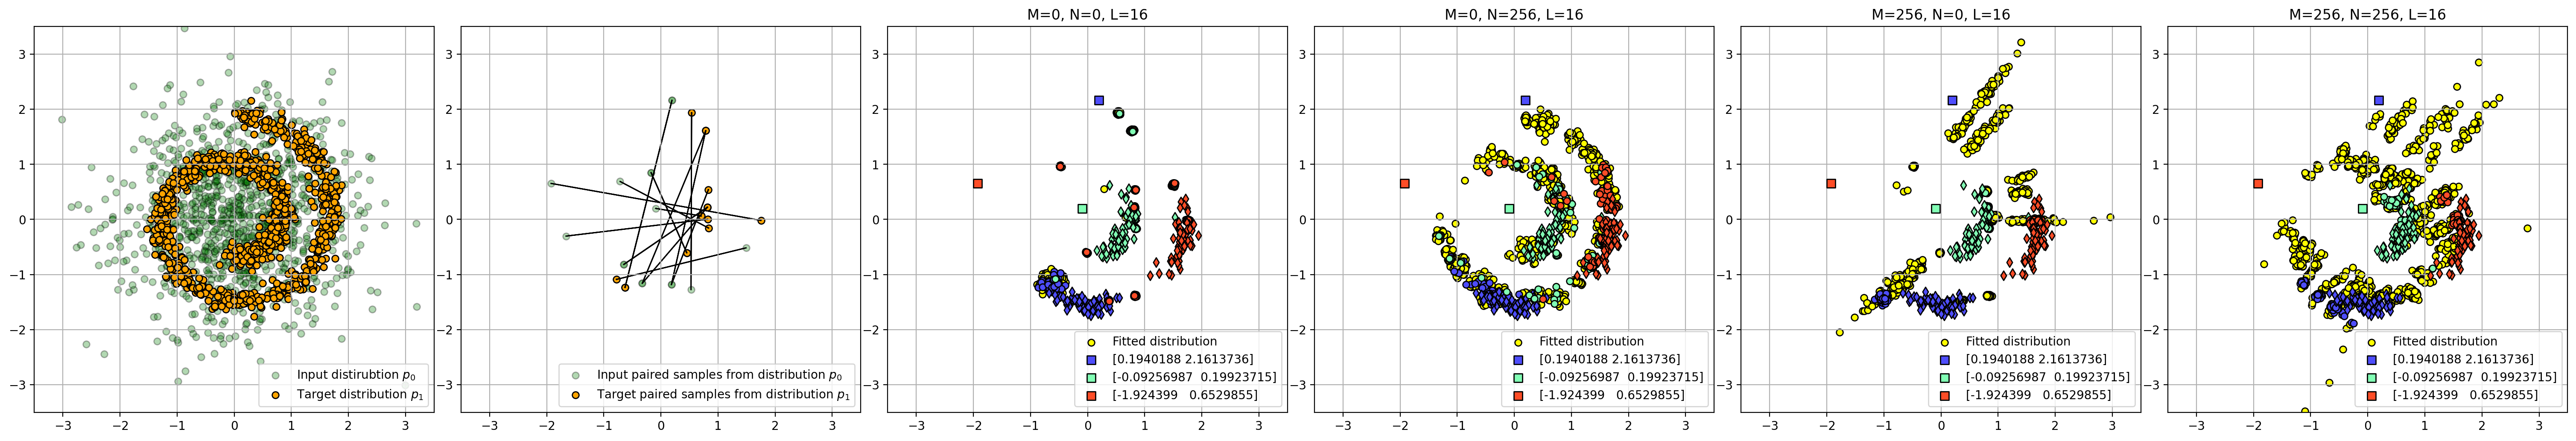

In [38]:
plot_swiss_roll(
    X_sampler,
    Y_sampler,
    M_X_unpaired_samples_list,
    N_Y_unpaired_samples_list,
    L_paired_samples,
    X_paired,
    Y_paired,
    starting_point_ind_list,
)

In [60]:
point = X_paired[0]

In [62]:
num_ending_points = 64

In [68]:
torch.cat((point[None, :], X_sampler.sample(num_ending_points - 1))).shape

torch.Size([64, 2])

In [79]:
x_start = torch.cat((point[None, :], X_sampler.sample(num_ending_points - 1)))
y_end = Y_sampler.sample(num_ending_points)

In [81]:
p = otp_sampler.get_map(x_start, y_end)

In [74]:
p[0]

array([0.00000000e+00, 0.00000000e+00, 1.85550584e-22, 0.00000000e+00,
       4.81176275e-19, 0.00000000e+00, 1.23332708e-19, 0.00000000e+00,
       6.89913560e-19, 6.29462688e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.26608528e-16,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.30158498e-16, 0.00000000e+00, 0.00000000e+00, 7.20686239e-03,
       2.27211432e-16, 0.00000000e+00, 8.62907213e-13, 4.00123457e-12,
       6.27280467e-20, 8.48624363e-19, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.21721375e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 7.52868979e-19, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.28400179e-16,
       0.00000000e+00, 1.30594608e-03, 5.18835335e-09, 0.00000000e+00,
       0.00000000e+00, 6.84069079e-17, 0.00000000e+00, 8.61651706e-12,
       0.00000000e+00, 1.78460691e-05, 0.00000000e+00, 0.00000000e+00,
      

In [82]:
y_end[np.argmax(p[0])]

tensor([-0.1194, -1.6223], device='cuda:0')